In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

In [2]:
# 1. VERİ SETİ
np.random.seed(42)
saat = np.sort(np.random.rand(100, 1) * 10, axis=0)
gelisim = 0.8 * saat**2 - 0.05 * saat**3 + np.random.normal(0, 2, (100, 1))


In [3]:
df = pd.DataFrame({
    'saat': saat.flatten(),    # .flatten() 2D olan diziyi 1D yapar
    'gelisim': gelisim.flatten()
})

In [4]:
X = df[['saat']]
y = df['gelisim']


In [5]:
# Train-Test split
X_train,X_test, y_train, y_test= train_test_split(X,y , test_size=0.2,random_state=15)


In [6]:
# Pipeline
pipe= Pipeline(
    [('Poly',PolynomialFeatures(degree=3)),
     ('Scaler',StandardScaler()),
     ('Linearregression',LinearRegression()) ])


In [7]:
pipe.fit(X_train,y_train)


,steps,"[('Poly', ...), ('Scaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,degree,3
,interaction_only,False
,include_bias,True
,order,'C'
,copy,True
,with_mean,True
,with_std,True


In [14]:
y_pred=pipe.predict(X_test)
print(y_pred)

[26.33468716  6.17063547 15.47632259 13.39139882 10.63052101 24.7883789
 29.86863313  0.85599424  0.4171617  16.27163527 17.83483145  6.67606257
  1.9858461  28.75228679  0.11439885  2.61787312 17.97145482  0.22235204
 30.07782501 30.50592083]


In [15]:

print(f"Test Seti R2 Skoru: {r2_score(y_test, y_pred):.4f}")
print(f"Eğitim Seti R2 Skoru: {pipe.score(X_train, y_train):.4f}")


Test Seti R2 Skoru: 0.9790
Eğitim Seti R2 Skoru: 0.9690


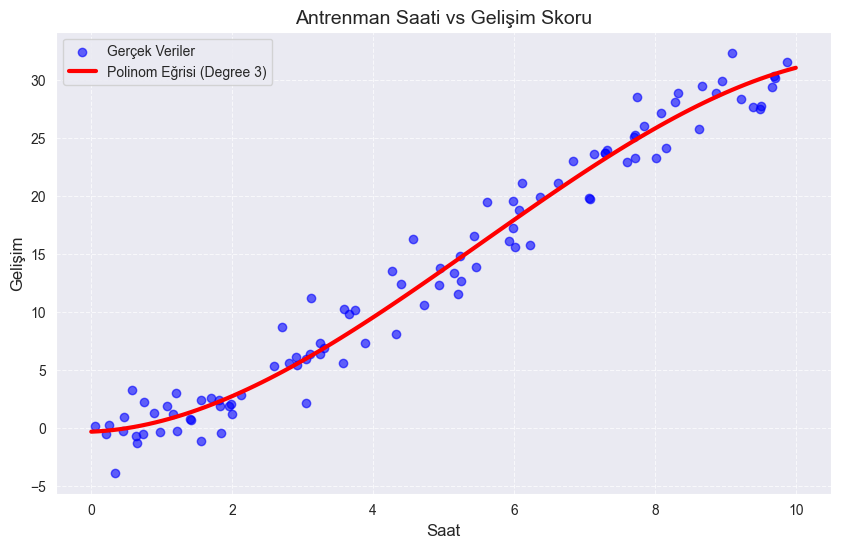

In [13]:
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', label='Gerçek Veriler', alpha=0.6)
X_siralı = np.linspace(0, 10, 100).reshape(-1, 1)
y_tahmin = pipe.predict(pd.DataFrame(X_siralı, columns=['saat']))

plt.plot(X_siralı, y_tahmin, color='red', linewidth=3, label='Polinom Eğrisi (Degree 3)')

plt.title('Antrenman Saati vs Gelişim Skoru', fontsize=14)
plt.xlabel('Saat', fontsize=12)
plt.ylabel('Gelişim', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()